In [1]:
# %pip install transformers==4.43.3

In [2]:
# %pip show transformers

In [1]:
import bitsandbytes as bnb
print('bnb version',bnb.__version__)
# print("GPU available:", bnb.cuda.is_available())
print("CUDA version:", bnb.cuda_specs.get_cuda_specs())

bnb version 0.49.0
CUDA version: CUDASpecs(highest_compute_capability=(8, 6), cuda_version_string='128', cuda_version_tuple=(12, 8))


In [2]:
import torch
import accelerate
print('accelerate version', accelerate.__version__)
print(torch.version.cuda, torch.cuda.is_available(), torch.__version__)

accelerate version 0.31.0
12.8 True 2.9.1+cu128


In [3]:
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration,BitsAndBytesConfig
from PIL import Image
import torch

# Load processor and model      
model_id = "llava-hf/llava-v1.6-mistral-7b-hf"
processor = LlavaNextProcessor.from_pretrained(model_id,
                                              trust_remote_code=True)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    # bnb_8bit_quant_type="nf4",
    # bnb_8bit_use_double_quant=True,
    # bnb_8bit_compute_type=torch.float16
)
model = LlavaNextForConditionalGeneration.from_pretrained(model_id, 
                                                        #   torch_dtype=torch.float16, 
                                                          low_cpu_mem_usage=True,
                                                          quantization_config=quantization_config)



Some kwargs in processor config are unused and will not have any effect: patch_size, vision_feature_select_strategy, image_token, num_additional_image_tokens. 


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
# from auto_gptq import AutoGPTQForCausalLM, BaseQuantizeConfig
# from transformers import AutoTokenizer

# model_name = 'llava-hf/llava-v1.6-mistral-7b'
# quant_config = BaseQuantizeConfig(bits=4, group_size=128, desc_act=False)
# tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
# model = AutoGPTQForCausalLM.from_quantized(model_name, 
#                                            quantize_config=quant_config)
# model.quantize(save_dir='./llava-mistral-7b-4bit')
# print("Quantization completed and model saved.")

In [7]:
# %pip install transformers -U

In [4]:
def describe_image(image_path,prompt):
    conversation = [
        {
          "role": "user",
          "content": [
              {"type": "text", "text": prompt},
              {"type": "image"},
            ],
        },
    ]
    if model.config.pad_token_id is None:
        model.config.pad_token_id = model.config.eos_token_id
        
    with Image.open(image_path) as image:
        prompt = processor.apply_chat_template(conversation, add_generation_prompt=False)
        inputs = processor(text=prompt, images=image, return_tensors="pt").to(model.device)
        with torch.inference_mode():
            output = model.generate(**inputs, 
                                    max_new_tokens=250,
                                    pad_token_id=model.config.pad_token_id,
                                    eos_token_id= model.config.eos_token_id
                                   )
        # print(inputs.input_ids.shape)
        description = processor.decode(output[0][len(inputs.input_ids[0]):], skip_special_tokens=True)
        return description



In [5]:
import re

def remove_prompt(output_text):
    generated_text = re.sub(r"\[INST\](.*?)\[/INST\]", 
                            "", 
                            output_text, 
                            flags=re.DOTALL).strip()
    return generated_text

In [6]:
## Captioning Method 2
caption_templates = {
    "dyed-lifted-polyps": {
        "medium": [
            "Endoscopic image of a dyed lifted polyp using chromoendoscopy.",
            "Blue-stained mucosa highlighting a lifted colonic polyp.",
            "Raised polyp area enhanced with dye for improved visualization.",
            "A lifted colorectal polyp visible with dye contrast application.",
            "Dye-assisted endoscopic view showing a clearly elevated polyp."
        ],
        "detailed": [
            "Endoscopic view of a lifted colorectal polyp after submucosal injection, with dye staining enhancing lesion visualization and margin definition.",
            "A chromoendoscopy image showing a polyp elevated from the mucosa, surrounded by blue dye to highlight its borders and structure.",
            "Dyed mucosal surface clearly outlines the raised polyp, aiding endoscopic inspection and planning for resection.",
            "Polyp lifted during endoscopic procedure with dye contrast enhancing the mucosal pattern and lesion boundary visibility.",
            "Detailed endoscopic appearance of a dyed-lifted polyp, showing smooth elevated tissue with enhanced visual contrast."
        ]
    },

    "dyed-resection-margins": {
        "medium": [
            "Dye-stained post-polypectomy resection margins.",
            "Marked mucosal borders following resection.",
            "Resection area highlighted with blue dye.",
            "Endoscopic view showing dyed resection margins.",
            "Dye-assisted margin visualization post-polyp removal."
        ],
        "detailed": [
            "Endoscopic image showing resection margins enhanced with dye to clearly define tissue edges after polypectomy.",
            "Post-resection mucosa with blue dye highlighting the excision boundary for residual lesion assessment.",
            "A dyed resection region displaying distinct edges, useful for evaluating healing and completeness of removal.",
            "Chromoendoscopy view demonstrating resection margins with marked boundaries using contrast dye.",
            "Dye-enhanced resection field, with tissue edges well outlined under endoscopy."
        ]
    },

    "esophagitis": {
        "medium": [
            "Inflamed esophageal mucosa indicating esophagitis.",
            "Reddened mucosa with visible irritation.",
            "Erosive esophagitis with mucosal breaks.",
            "Endoscopic view of irritated esophageal lining.",
            "Signs of mucosal inflammation in the esophagus."
        ],
        "detailed": [
            "Endoscopic appearance of esophagitis showing erythematous mucosa, erosions, and inflammatory tissue changes along the esophageal wall.",
            "Severe mucosal redness and surface irritation consistent with reflux-related esophagitis.",
            "Inflamed esophagus with patchy erosions and visible irritation, commonly associated with chronic acid exposure.",
            "Esophageal lining displaying continuous inflammation with mucosal swelling and erythema.",
            "Diffuse inflammatory changes in esophageal mucosa, showing erosions and red streaking patterns."
        ]
    },

    "normal-cecum": {
        "medium": [
            "Normal cecum with healthy mucosal pattern.",
            "Endoscopic view of a normal cecum.",
            "Healthy tissue appearance in cecal region.",
            "Clear colonoscopic view of normal cecum.",
            "Cecum showing no abnormal lesions or inflammation."
        ],
        "detailed": [
            "Healthy cecum with smooth mucosal surface, intact vascular pattern, and no evidence of inflammation or lesions.",
            "Endoscopic view of a normal cecum showing uniform coloration and structural integrity.",
            "Well-visualized cecum with no signs of polyps, ulceration, or mucosal abnormality.",
            "Normal colon anatomy with smooth cecal mucosa appearing pink and well perfused.",
            "Clear image of the cecum demonstrating normal morphology and tissue health."
        ]
    },

    "normal-pylorus": {
        "medium": [
            "Endoscopic view of a normal pylorus.",
            "Healthy pyloric opening with smooth mucosa.",
            "Normal gastric outlet with no visible lesions.",
            "Pylorus appearing structurally normal and unobstructed.",
            "Smooth mucosal folds around the pylorus."
        ],
        "detailed": [
            "Well-defined pylorus displaying smooth mucosal folds and an open gastric outlet with no signs of inflammation or ulceration.",
            "Endoscopic image showing a normal pyloric ring with healthy tissue and regular anatomy.",
            "Gastric outlet region showing normal morphology and mucosal integrity.",
            "Healthy pylorus with uniform mucosal color and no obstructive features.",
            "Normal pyloric canal visualized with intact mucosa and clear lumen."
        ]
    },

    "normal-z-line": {
        "medium": [
            "Normal z-line at gastroesophageal junction.",
            "Healthy squamocolumnar junction appearance.",
            "Endoscopic view of normal z-line.",
            "Clear transition between esophageal and gastric mucosa.",
            "No abnormalities seen at z-line interface."
        ],
        "detailed": [
            "Endoscopic visualization of a normal z-line showing a clean demarcation between squamous and columnar epithelium.",
            "Healthy gastroesophageal junction with intact mucosal pattern and no erosive changes.",
            "Well-defined z-line without signs of Barrett’s esophagus or inflammation.",
            "Normal z-line appearance with clear epithelial transition and smooth mucosa.",
            "Regular mucosal interface between esophagus and stomach with no abnormalities detected."
        ]
    },

    "polyps": {
        "medium": [
            "Colonic polyp visible during endoscopy.",
            "Single sessile polyp on mucosal surface.",
            "Pedunculated polyp protruding from colon wall.",
            "Polypoid lesion observed in colonoscopy.",
            "Raised lesion suggestive of polyp formation."
        ],
        "detailed": [
            "Endoscopic image showing a colonic polyp protruding from mucosa, potentially requiring biopsy or resection.",
            "A visible polyp with defined edges and smooth lobulated surface under colonoscopic view.",
            "Polypoid growth in the colon with elevated tissue structure and distinct appearance.",
            "Single or multiple polyps visualized on mucosal folds during endoscopy.",
            "Protruding colorectal lesion consistent with polyp formation, with surrounding mucosa visible."
        ]
    },

    "ulcerative-colitis": {
        "medium": [
            "Inflamed colon mucosa indicating ulcerative colitis.",
            "Diffuse mucosal erosion with ulcer patches.",
            "Colon tissue showing redness and friability.",
            "Endoscopic signs of ulcerative inflammation.",
            "Granular mucosa appearance with ulceration."
        ],
        "detailed": [
            "Endoscopic view showing severe ulcerative colitis with inflamed, erythematous mucosa and scattered ulcerations.",
            "Diffuse continuous inflammation of colon lining with friable tissue and visible ulcer beds.",
            "Active ulcerative colitis presenting with mucosal bleeding, granular surface, and loss of vascular pattern.",
            "Colonic mucosa exhibiting widespread erosions and inflammatory patches consistent with UC.",
            "Severe mucosal damage and ulcerations throughout affected region, typical of active ulcerative colitis."
        ]
    }
}

prompt_v6 = f""" You are generating captions for training a diffusion image model.
    
    Describe ONLY what is directly visible in the endoscopic image. Do NOT infer diagnosis, severity, or absence of findings. Do NOT use negations such as "no","not visible", 
    or "without". 
    
    Focus on: 
    - anatomy (e.g. colonic mucosa)
    - color
    - shape
    - surface texture
    - lighting and photographic style
    - geometry (e.g. folded mucosa, circular lumen, flat field, or curved intestinal wall)
    
    Write a SINGLE short caption using comma-separated visual phrases. Limit to 40-50 tokens.
    
    Begin the caption with 'KVasir_style medical endoscopic image of {0}'. Avoid full sentences. Avoid explanations.
    
    Now generate the caption.
    """

prompt_v7= """Describe this colon endoscopic image of {0} from Kvasir dataset in extreme detail for a text-to-image training dataset. 
Focus strictly on visual attributes. Do NOT infer diagnosis, severity, or absence of findings.
Describe the central subject's shape and texture, the specific colors (including any dye staining), the surrounding tissue, lighting reflections, and explicitly mention any digital overlays, text, or UI graphics present in the frame. 
Do not use conversational filler.  Write a SINGLE short caption using comma-separated visual phrases. Limit to 40-50 words.
Avoid full sentences. Avoid explanations.

"""

prompt_v8="""Provide a comprehensive caption for this colon endoscopic image of {0}. Follow this structure:

Identify the main anatomical subject and its color.

Describe the texture and any dyes or staining visible.

Describe the background and lighting (reflections/glare).

Describe all technical overlays, including text timestamp, patient data placeholders, and the green scope orientation graphic.

Limit to 40-50 words.

Avoid full sentences. Avoid explanations. DO NOT explain, clarify or report.

"""


import json

def build_caption_prompt(class_name):
    """
    Generates the system+instruction prompt for an LLM
    with templates embedded dynamically for the given class.
    """

    class_templates = json.dumps(caption_templates[class_name], indent=2)

    prompt = f"""
You are a medical endoscopy captioning model.
Below are caption style templates for the class '{class_name}':

TEMPLATES:
{class_templates}

TASK:
Generate two captions for an input image:
1. A medium caption (short 8-15 words)
2. A detailed caption (20-40 words using clinical language)

Follow style patterns shown in templates but write new sentences,
do not repeat phrases verbatim.

Return ONLY in JSON format:
{{
  "medium": "...",
  "detailed": "..."
}}
"""
    return prompt


In [7]:
# Generate captions for Kvasir dataset - Training data
import os
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np

categories={
        'dyed-lifted-polyps':'dyed lifted polyps',
        'dyed-resection-margins':'dyed resection margins',
        'esophagitis':'esophagitis',
        'normal-cecum':'normal cecum',
        'normal-pylorus':'normal pylorus',
        'normal-z-line':'normal z-line',
            'polyps':'polyps',
            'ulcerative-colitis':'ulcerative colitis'
        }

data_root = r'/home/qzhao9/datasets/kvasir-dataset'

In [ ]:
def caption_img_train():
    output_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv'
    last_results = pd.DataFrame([])
    training_img = []
    if os.path.isfile(output_file):
        last_results = pd.read_csv(output_file)
        training_img = last_results['img'].tolist()
        # last_results = last_results.drop(columns=['Unnamed: 0','Unnamed: 0.1'], errors='ignore')
    category_stats = {}
    image_desc = []
    np.random.seed(27)
    for folder, category in tqdm(categories.items(), desc='Describe Images'):
        folder_path = data_root + '/' + folder
        images =  os.listdir(folder_path)
        images = [img for img in images if img.endswith('.jpg')]
        # prompt = f"""You are a medical endoscopy captioning model. Please describe the endoscopic image of {category} using the following visual features: specific color, shape, surrounding mucosa, surface texture, bleeding condition, and other relevant details to serve the diagnosis purpose. 
        #            Start with ‘An endoscopic image of {category}’. Make sure the description is concise, and limit the description tokens betwen 60 and 75"""
        # prompt = build_caption_prompt(folder)

        prompt = prompt_v8.format(category) #prompt_v7.format(category)
        image_desc = []
        np.random.shuffle(images)
        for img in tqdm(images[:250], desc=folder):
            if img in training_img:
                continue
            img_path = folder_path + '/' + img
            desc = describe_image(image_path=img_path, prompt=prompt)
            # print(desc)
            image_desc.append({'category':folder, 'img': img, 'desc':desc})
            # break
        last_results = pd.concat([last_results, pd.DataFrame(image_desc)], ignore_index=True)
        last_results.to_csv(output_file, index=False)
        print(f'Saved intermediate results to {output_file}')
        # category_stats[folder] = len(images)
        # category_stats[folder] = len(images)

# print(category_stats)

Describe Images:   0%|          | 0/8 [00:00<?, ?it/s]

dyed-lifted-polyps:   0%|          | 0/250 [00:00<?, ?it/s]

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv


dyed-resection-margins:   0%|          | 0/250 [00:00<?, ?it/s]

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv


...

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv


polyps:   0%|          | 0/250 [00:00<?, ?it/s]

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv


ulcerative-colitis:   0%|          | 0/250 [00:00<?, ?it/s]

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv


In [8]:
# Generate captions for Kvasir dataset - Test data

def caption_img_test():
    train_data_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv'
    output_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv'
    last_results = pd.DataFrame([])
    training_img = []
    if os.path.isfile(train_data_file):
        prev_results = pd.read_csv(train_data_file)
        training_img = prev_results['img'].tolist()

    image_desc = []
    np.random.seed(27)
    for folder, category in tqdm(categories.items(), desc='Describe Images'):
        folder_path = data_root + '/' + folder
        images =  os.listdir(folder_path)
        images = [img for img in images if img.endswith('.jpg') and img not in training_img]

        prompt = prompt_v8.format(category) #prompt_v7.format(category)
        image_desc = []
        np.random.shuffle(images)
        for img in tqdm(images[:125], desc=folder):
            img_path = folder_path + '/' + img
            desc = describe_image(image_path=img_path, prompt=prompt)
            # print(desc)
            image_desc.append({'category':folder, 'img': img, 'desc':desc})
            # break
        last_results = pd.concat([last_results, pd.DataFrame(image_desc)], ignore_index=True)
        last_results.to_csv(output_file, index=False)
        print(f'Saved intermediate results to {output_file}')


caption_img_test()

Describe Images:   0%|          | 0/8 [00:00<?, ?it/s]

dyed-lifted-polyps:   0%|          | 0/125 [00:00<?, ?it/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv


dyed-resection-margins:   0%|          | 0/125 [00:00<?, ?it/s]

...

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv


polyps:   0%|          | 0/125 [00:00<?, ?it/s]

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv


ulcerative-colitis:   0%|          | 0/125 [00:00<?, ?it/s]

Saved intermediate results to /home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv


In [9]:
# Remove any overlapping images between train and test set

train_data_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_partial_8.8.csv'
output_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv'

pd_train = pd.read_csv(train_data_file)
pd_test = pd.read_csv(output_file)

pd_test.info()

# pd_test2 = pd_test[pd_test['img'].isin(pd_train['img'])]
# pd_test2.info()
# pd_test2.to_csv(output_file, index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  1000 non-null   object
 1   img       1000 non-null   object
 2   desc      1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


In [13]:
# Release GPU memory
# del model
# torch.cuda.empty_cache()
# import gc
# gc.collect()    

In [14]:
# import csv

# file_name = 'image_description.csv'
# with open(file_name,mode='w', encoding='utf-8', newline='') as f:
#     writer = csv.DictWriter(f,fieldnames=['category','img','desc'], quoting=csv.QUOTE_ALL)
#     writer.writeheader()
#     for record in image_desc:
#         writer.writerow(record)

## Prepare Dataset for Compressor

In [15]:
# import pandas as pd

# image_desc_file = 'C:\COMP9800\Dataset\kvasir-dataset\image_description_partial.csv'

# data = pd.read_csv(image_desc_file)
# description = data.iloc[:,2]

In [16]:
# help(summarizer)

In [17]:
# from transformers import pipeline

# summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

In [18]:
# long_text = description.to_list()
# results=[]
# for t in long_text:
#     summ = summarizer(t, max_length=75, min_length=60, do_sample=False)
#     results.append(summ)



  

  Before Albumentation: numpy==1.26.3 scipy==1.11.4
  After  Albumentation: numpy==2.2.6  scipy==1.16.3
    


In [119]:
%matplotlib inline


In [1]:
import albumentations as A
import cv2
from matplotlib import pyplot as plt

font_path = "../data/documents/LiberationSerif-Regular.ttf"

BOX_COLOR = (255, 0, 0)  # Red
TEXT_COLOR = (255, 255, 255)  # White


def visualize_bbox(img, bbox, class_name, color=BOX_COLOR, thickness=2):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, x_max, y_max = bbox
    x_min, x_max, y_min, y_max = int(x_min), int(x_max), int(y_min), int(y_max)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=color, thickness=thickness)

    ((text_width, text_height), _) = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv2.rectangle(img, (x_min, y_min - int(1.3 * text_height)), (x_min + text_width, y_min), BOX_COLOR, -1)
    cv2.putText(
        img,
        text=class_name,
        org=(x_min, max(text_height,y_min - int(0.3 * text_height))),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.35,
        color=TEXT_COLOR,
        lineType=cv2.LINE_AA,
    )
    return img


def visualize(image, bboxes, category_ids, category_id_to_name):
    img = image.copy()
    for bbox, category_id in zip(bboxes, category_ids):
        class_name = category_id_to_name[category_id]
        img = visualize_bbox(img, bbox, class_name)
    plt.figure(figsize=(12, 12))
    plt.axis("off")
    plt.imshow(img)


In [5]:
bboxes = [[38,5,430,338]]
category_ids = [1]

# We will use the mapping from category_id to the class name
# to visualize the class label for the bounding box on the image
category_id_to_name = {1: "Polyp"}


(529, 622, 3)


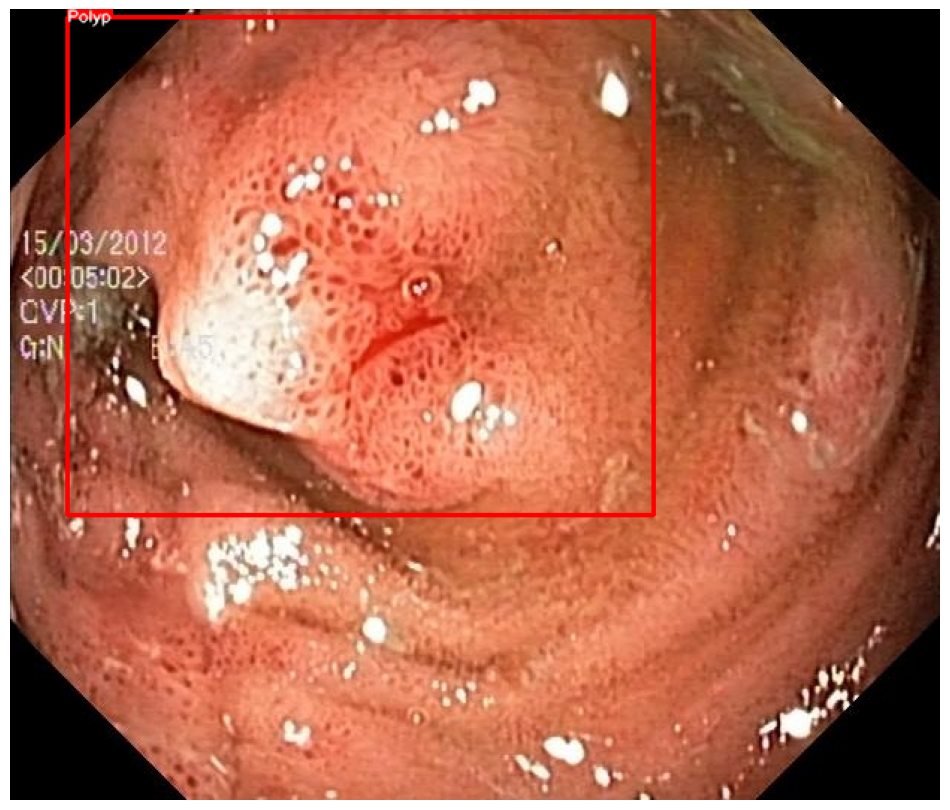

In [6]:
img_path = "/home/qzhao9/datasets/Kvasir-SEG/images/cju0qkwl35piu0993l0dewei2.jpg"
image = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
print(image.shape)
# image = cv2.resize(image, (500, 370))
visualize(image, bboxes, category_ids, category_id_to_name)

In [ ]:
transform = A.Compose(
    [A.BBoxSafeRandomCrop(erosion_rate=0.0, p=0.6),
     A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
     A.CLAHE(clip_limit=4.0, p=0.5),
     A.Rotate(limit=90, p=0.5),
     A.ZoomBlur(max_factor=[1.01,1.05], p=0.5)],
    bbox_params=A.BboxParams(format="pascal_voc", label_fields=["category_ids"]),
    seed=137,
    strict=True,
)


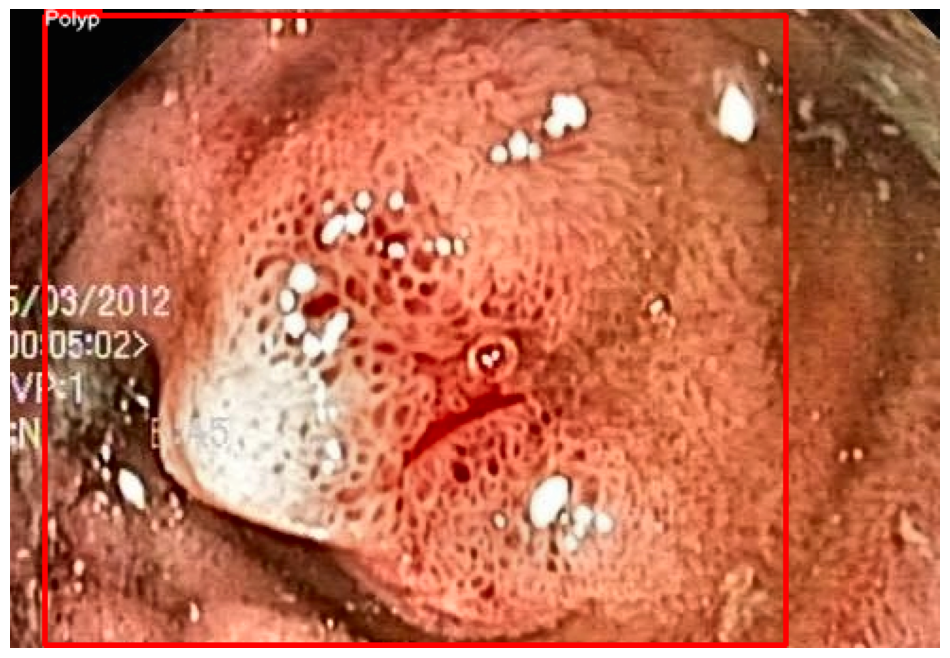

In [79]:
transformed = transform(image=image, bboxes=bboxes, category_ids=category_ids)
visualize(
    transformed["image"],
    transformed["bboxes"],
    transformed["category_ids"],
    category_id_to_name,
)
